In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

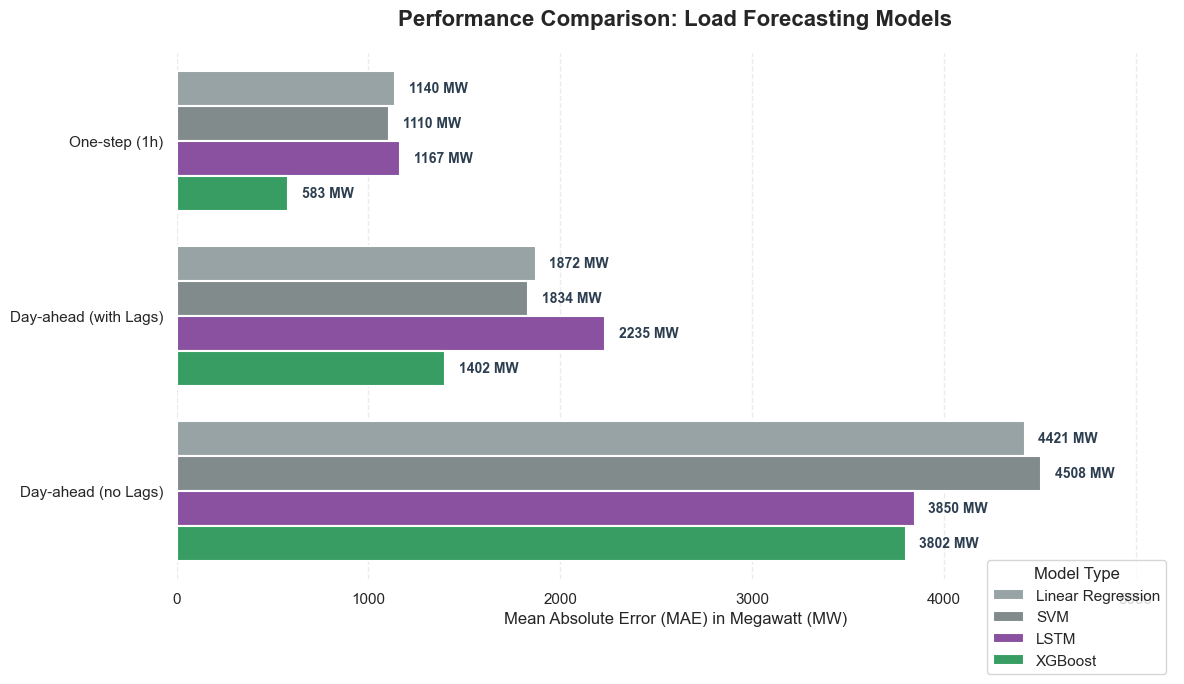

In [7]:
# 1. Daten definieren
data = {
    'Model': ['Linear Regression', 'SVM', 'LSTM', 'XGBoost'] * 3,
    'Scenario': ['One-step (1h)'] * 4 + ['Day-ahead (with Lags)'] * 4 + ['Day-ahead (no Lags)'] * 4,
    'MAE': [1140, 1110, 1167, 583, 1872, 1834, 2235, 1402, 4421, 4508, 3850, 3802]
}
df = pd.DataFrame(data)

# 2. Style-Einstellungen
sns.set_theme(style="white")
# Custom Palette: Grau-Töne für Klassik, Lila für LSTM, Grün für den Champion XGBoost
custom_palette = ["#95a5a6", "#7f8c8d", "#8e44ad", "#27ae60"]

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=df, 
    x='MAE', 
    y='Scenario', 
    hue='Model', 
    palette=custom_palette,
    edgecolor="white",
    linewidth=1.5
)

# 3. Werte an die Balken schreiben
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{int(width)} MW', 
                    (width + 70, p.get_y() + p.get_height() / 2), 
                    ha='left', va='center', 
                    fontsize=10, fontweight='bold', color='#2c3e50')

plt.title('Performance Comparison: Load Forecasting Models', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mean Absolute Error (MAE) in Megawatt (MW)', fontsize=12)
plt.ylabel('')
plt.xlim(0, 5200) # Platz für Labels schaffen
plt.legend(title='Model Type', frameon=True, loc='upper right', bbox_to_anchor=(1, 0.05))
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

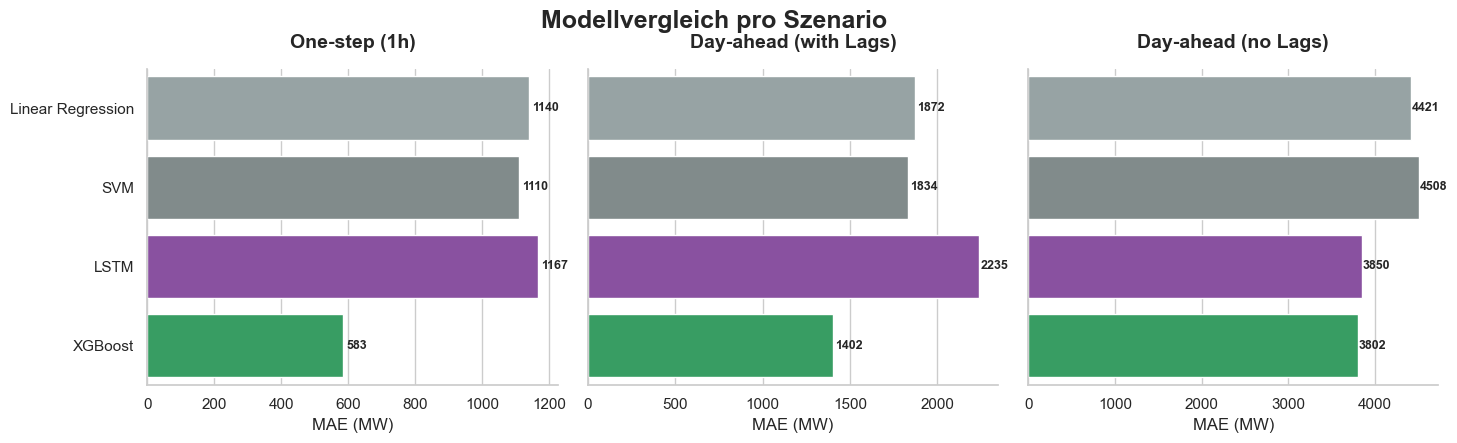

In [11]:
# Faceted Plot - Jedes Szenario in einem eigenen Panel
g = sns.catplot(
    data=df, kind="bar",
    x="MAE", y="Model", col="Scenario",
    hue="Model", palette=custom_palette, height=4.5, aspect=1.1,
    legend=False, sharex=False # Unterschiedliche X-Achsen für bessere Sichtbarkeit
)

g.set_titles("{col_name}", size=14, fontweight='bold', pad=15)
g.set_axis_labels("MAE (MW)", "")

# Labels hinzufügen
for ax in g.axes.flat:
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{int(width)}', 
                    (width + 10, p.get_y() + p.get_height() / 2), 
                    ha='left', va='center', fontsize=9, fontweight='bold')

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Modellvergleich pro Szenario', fontsize=18, fontweight='bold')
plt.show()

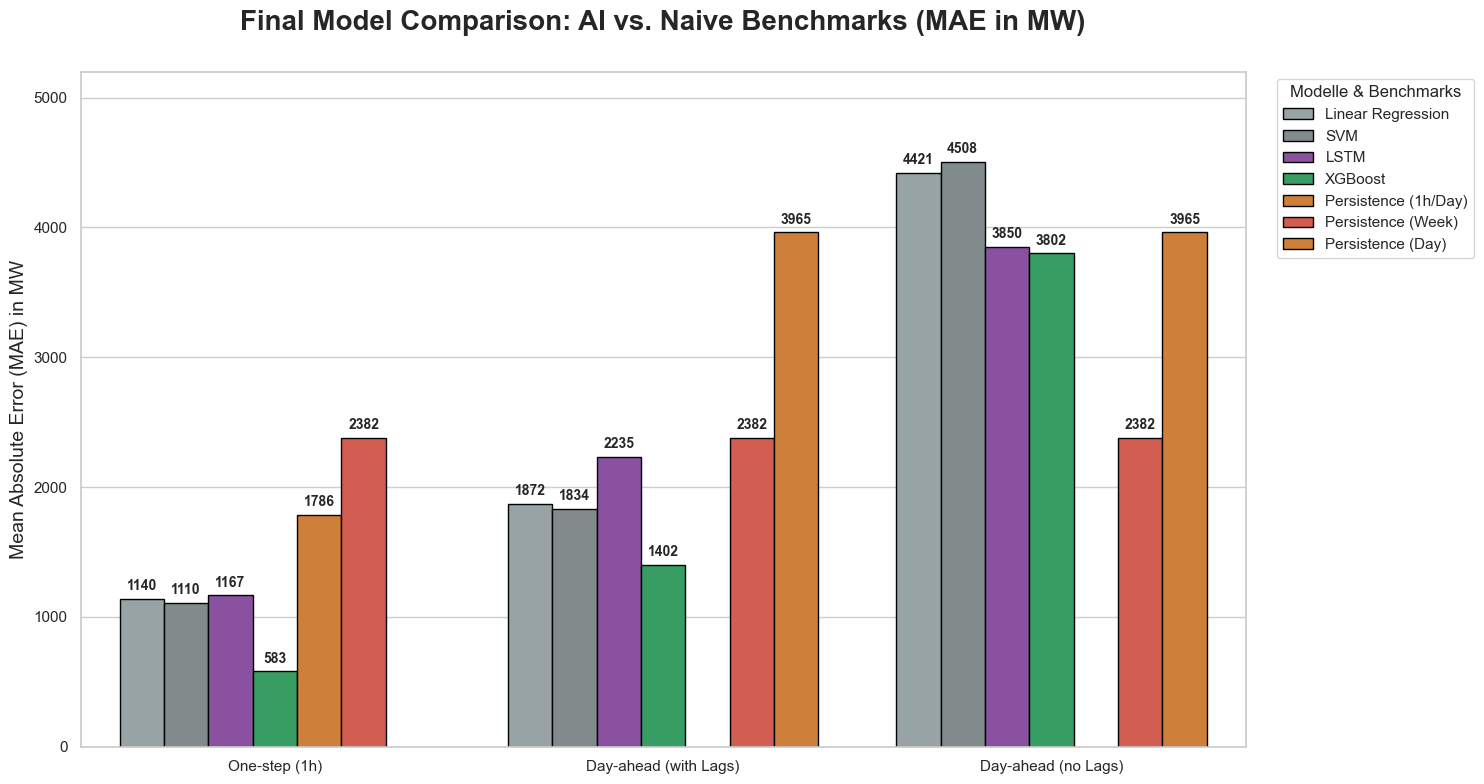

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Model': [
        'Linear Regression', 'SVM', 'LSTM', 'XGBoost', 'Persistence (1h/Day)', 'Persistence (Week)',
        'Linear Regression', 'SVM', 'LSTM', 'XGBoost', 'Persistence (Day)', 'Persistence (Week)',
        'Linear Regression', 'SVM', 'LSTM', 'XGBoost', 'Persistence (Day)', 'Persistence (Week)'
    ],
    'Scenario': [
        'One-step (1h)', 'One-step (1h)', 'One-step (1h)', 'One-step (1h)', 'One-step (1h)', 'One-step (1h)',
        'Day-ahead (with Lags)', 'Day-ahead (with Lags)', 'Day-ahead (with Lags)', 'Day-ahead (with Lags)', 'Day-ahead (with Lags)', 'Day-ahead (with Lags)',
        'Day-ahead (no Lags)', 'Day-ahead (no Lags)', 'Day-ahead (no Lags)', 'Day-ahead (no Lags)', 'Day-ahead (no Lags)', 'Day-ahead (no Lags)'
    ],
    'MAE': [
        1140, 1110, 1167, 583, 1786, 2382,  # One-step (aktualisiert)
        1872, 1834, 2235, 1402, 3965, 2382, # Day-ahead (Lag)
        4421, 4508, 3850, 3802, 3965, 2382  # Day-ahead (No Lag)
    ]
}
df_all = pd.DataFrame(data)

# 2. Style-Einstellungen
sns.set_theme(style="whitegrid")
custom_colors = {
    'Linear Regression': '#95a5a6', 
    'SVM': '#7f8c8d', 
    'LSTM': '#8e44ad', 
    'XGBoost': '#27ae60', # Gewinner in Grün
    'Persistence (1h/Day)': '#e67e22', # Benchmark in Orange
    'Persistence (Day)': '#e67e22', 
    'Persistence (Week)': '#e74c3c'  # Wochen-Benchmark in Rot
}

plt.figure(figsize=(15, 8))
ax = sns.barplot(data=df_all, x='Scenario', y='MAE', hue='Model', palette=custom_colors, edgecolor="black")
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2., h), 
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.title('Final Model Comparison: AI vs. Naive Benchmarks (MAE in MW)', fontsize=20, fontweight='bold', pad=30)
plt.ylabel('Mean Absolute Error (MAE) in MW', fontsize=14)
plt.xlabel('')
plt.ylim(0, 5200)
plt.legend(title='Modelle & Benchmarks', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()

plt.show()